# Regressão Logística

## Importando as Bibliotecas

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importando a Base de Dados

In [100]:
dados = pd.read_excel('train.xlsx')

In [101]:
dados

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,712833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,2021-05-08 00:00:00,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30,C148,C


In [102]:
dados.Age = dados.Age.fillna(0)

In [103]:
dados.Age.unique()

array([22, 38, 26, 35, 0, 54, 2, 27, 14, 4, 58, 20, 39, 55, 31, 34, 15,
       28, 8, 19, 40, 66, 42, 21, 18, 3, 7, 49, 29, 65,
       datetime.datetime(2021, 5, 28, 0, 0), 5, 11, 45, 17, 32, 16, 25,
       '0.83', 30, 33, 23, 24, 46, 59, 71, 37, 47,
       datetime.datetime(2021, 5, 14, 0, 0), '70.5', '32.5', 12, 9,
       '36.5', 51, '55.5', '40.5', 44, 1, 61, 56, 50, 36, '45.5',
       datetime.datetime(2021, 5, 20, 0, 0), 62, 41, 52, 63,
       datetime.datetime(2021, 5, 23, 0, 0), '0.92', 43, 60, 10, 64, 13,
       48, '0.75', 53, 57, 80, 70, datetime.datetime(2021, 5, 24, 0, 0),
       6, '0.67', datetime.datetime(2021, 5, 30, 0, 0), '0.42', '34.5',
       74], dtype=object)

In [104]:
dados['Age'] = pd.to_numeric(dados['Age'], errors='coerce').fillna(0)

In [105]:
dados.Age.unique()

array([22.  , 38.  , 26.  , 35.  ,  0.  , 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  ,  5.  , 11.  , 45.  , 17.  , 32.  , 16.  ,
       25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  , 71.  ,
       37.  , 47.  , 70.5 , 32.5 , 12.  ,  9.  , 36.5 , 51.  , 55.5 ,
       40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  , 45.5 , 62.  ,
       41.  , 52.  , 63.  ,  0.92, 43.  , 60.  , 10.  , 64.  , 13.  ,
       48.  ,  0.75, 53.  , 57.  , 80.  , 70.  ,  6.  ,  0.67,  0.42,
       34.5 , 74.  ])

In [106]:

dados['Fare'] = pd.to_numeric(dados['Fare'], errors='coerce').fillna(0)

In [107]:
dados.Cabin = dados.Cabin.fillna('n_identificado')

In [108]:
dados.Embarked = dados.Embarked.fillna('n_identificado')

In [109]:
dados = dados.drop(['Ticket','PassengerId'], axis = 1)

In [110]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

colunas = pd.DataFrame(dados.dtypes).reset_index().rename(columns={'index': 'nome', 0: 'tipo'})
categ_cols = colunas[colunas.tipo  == 'object']



dados = pd.get_dummies(dados, columns=categ_cols['nome'], prefix=[col + "_encoded" for col in categ_cols['nome']])


## Separando a Base em Treino e Teste

In [111]:
from sklearn.model_selection import train_test_split

x = dados.drop('Survived', axis = 1)
y = dados.Survived

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 0)

## Padronização dos Dados

In [112]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

## Treinando o Modelo

In [113]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Prevendo o Resultado do Conjunto de Teste

In [114]:
y_pred = classifier.predict(x_test)

## Matriz de Confusão

In [115]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

0.8097014925373134


In [116]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)


Na Matriz de Confusão, o primeiro argumento dado para a função fica no eixo y, e o segundo argumento no eixo x

Portando para o nosso exemplo, os valores reais ficam na vertical, e os previstos na horizontal

In [117]:
len(x_test)

268

<Axes: >

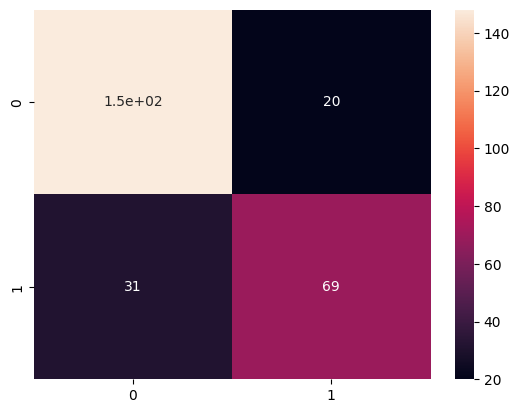

In [118]:
import seaborn as sns

sns.heatmap(cm, annot=True)



```
# Isto está formatado como código
```

## Curva ROC

Text(0.5, 1.0, 'Curva ROC')

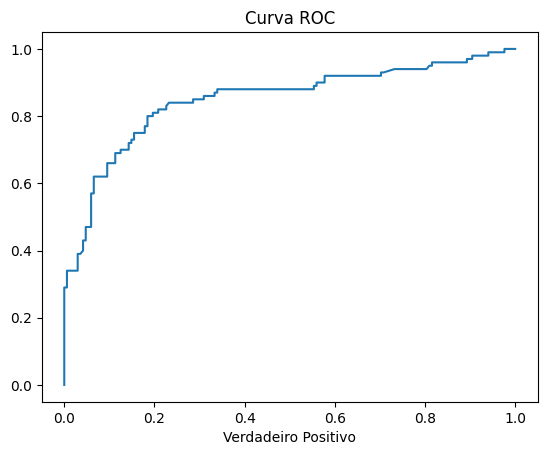

In [119]:
from sklearn.metrics import roc_curve
prob = classifier.predict_proba(x_test)
prob = prob[:,1]
fpr, tpr, threshold = roc_curve(y_test, prob)

plt.plot(fpr, tpr)
plt.xlabel('Falso Positivo')
plt.xlabel('Verdadeiro Positivo')
plt.title('Curva ROC')

## Precision e Recall

In [120]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

0.7752808988764045
0.69
0.7301587301587301
